In [1]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine

In [2]:
# PostgreSQL connection details
username = 'postgres'
password = 'admin'
host = 'localhost'
port = '5432'
database = 'analytics_db'

# Create connection using create_engine (which acts as 
# the main interface between Python code and the database)
engine = create_engine(
    f'postgresql+pg8000://{username}:{password}@{host}:{port}/{database}'
    )

# Fetch the data from PostgreSQL analytics_db server - gold layer
df_raw = pd.read_sql(
    'SELECT * ' \
    'FROM gold.weather_observations',
    con=engine 
    # con=engine in pd.read_sql() tells pandas which 
    # database connection to use when executing the SQL query
)

## Inspect df

In [3]:
df_raw.head()

,station,station_name,elevation,observation_date,month_year,metric,value
0,PL000012120,Leba,2.0,2015-01-01,01-2015,TMAX,5.4
1,PL000012120,Leba,2.0,2015-01-01,01-2015,TMIN,1.2
2,PL000012120,Leba,2.0,2015-01-01,01-2015,PRCP,0.0
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0
4,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TMAX,1.5


In [4]:
df_raw['metric'].unique()

<StringArray>
['TMAX', 'TMIN', 'PRCP', 'TAVG', 'SNWD']
Length: 5, dtype: str

In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 137418 entries, 0 to 137417
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   station           137418 non-null  str    
 1   station_name      137418 non-null  str    
 2   elevation         137418 non-null  float64
 3   observation_date  137418 non-null  object 
 4   month_year        137418 non-null  str    
 5   metric            137418 non-null  str    
 6   value             137418 non-null  float64
dtypes: float64(2), object(1), str(4)
memory usage: 7.3+ MB


In [6]:
df_raw['observation_date'].min()

datetime.date(2015, 1, 1)

In [7]:
df_raw['observation_date'].max()

datetime.date(2026, 6, 29)

In [8]:
# Convert observation_date to date
df = df_raw.copy()
df['observation_date'] = pd.to_datetime(df['observation_date'])

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 137418 entries, 0 to 137417
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype        
---  ------            --------------   -----        
 0   station           137418 non-null  str          
 1   station_name      137418 non-null  str          
 2   elevation         137418 non-null  float64      
 3   observation_date  137418 non-null  datetime64[s]
 4   month_year        137418 non-null  str          
 5   metric            137418 non-null  str          
 6   value             137418 non-null  float64      
dtypes: datetime64[s](1), float64(2), str(4)
memory usage: 7.3 MB


In [10]:
df_raw.isna().sum()

station             0
station_name        0
elevation           0
observation_date    0
month_year          0
metric              0
value               0
dtype: int64

In [11]:
df_raw["metric"].value_counts()

metric
TAVG    40542
PRCP    36471
TMAX    33319
TMIN    23113
SNWD     3973
Name: count, dtype: int64

In [12]:
df_raw["observation_date"].min(), df_raw["observation_date"].max()

(datetime.date(2015, 1, 1), datetime.date(2026, 6, 29))

In [58]:
sorted(df['station_name'].unique())

['Balice',
 'Bialystok',
 'Elblag-Milejewo',
 'Lawica',
 'Leba',
 'Okecie',
 'Siedlce',
 'Strachowice',
 'Szczecin',
 'Wlodawa']

## Analyze the trend in Poland's average annual temperature (2015-2025)

#### Extract TAVG metric and calculate min/max date

In [13]:
# Filter out TAVG metric and 2015-2025 
df = df_raw.copy()

df['observation_date'] = pd.to_datetime(df['observation_date'])

df = (df[
    (df['metric'] == 'TAVG') & 
    (df['observation_date'] < "2026-01-01")
].sort_values(
    'observation_date',
    axis=0,
    ascending=True
)
)

df

,station,station_name,elevation,observation_date,month_year,metric,value
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9
...,...,...,...,...,...,...,...
121137,PL000012385,Siedlce,152.0,2025-12-31,12-2025,TAVG,-4.1
121141,PLM00012160,Elblag-Milejewo,43.0,2025-12-31,12-2025,TAVG,-4.0
121145,PLM00012205,Szczecin,7.0,2025-12-31,12-2025,TAVG,-1.1
121149,PLM00012295,Bialystok,151.0,2025-12-31,12-2025,TAVG,-9.2


In [14]:
# Extract year from observation_date
df['year'] = df['observation_date'].dt.year

df

,station,station_name,elevation,observation_date,month_year,metric,value,year
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0,2015
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7,2015
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4,2015
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0,2015
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9,2015
...,...,...,...,...,...,...,...,...
121137,PL000012385,Siedlce,152.0,2025-12-31,12-2025,TAVG,-4.1,2025
121141,PLM00012160,Elblag-Milejewo,43.0,2025-12-31,12-2025,TAVG,-4.0,2025
121145,PLM00012205,Szczecin,7.0,2025-12-31,12-2025,TAVG,-1.1,2025
121149,PLM00012295,Bialystok,151.0,2025-12-31,12-2025,TAVG,-9.2,2025


In [52]:
df['min_obs_date'] = df['observation_date'].min()
df['max_obs_date'] = df['observation_date'].max()

df

,station,station_name,elevation,observation_date,month_year,metric,value,year,min_obs_date,max_obs_date
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0,2015,2015-01-01,2025-12-31
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7,2015,2015-01-01,2025-12-31
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4,2015,2015-01-01,2025-12-31
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0,2015,2015-01-01,2025-12-31
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9,2015,2015-01-01,2025-12-31
...,...,...,...,...,...,...,...,...,...,...
121137,PL000012385,Siedlce,152.0,2025-12-31,12-2025,TAVG,-4.1,2025,2015-01-01,2025-12-31
121141,PLM00012160,Elblag-Milejewo,43.0,2025-12-31,12-2025,TAVG,-4.0,2025,2015-01-01,2025-12-31
121145,PLM00012205,Szczecin,7.0,2025-12-31,12-2025,TAVG,-1.1,2025,2015-01-01,2025-12-31
121149,PLM00012295,Bialystok,151.0,2025-12-31,12-2025,TAVG,-9.2,2025,2015-01-01,2025-12-31


#### Data quality assessment

To improve the reliability of the analysis, station coverage was evaluated before calculating annual average temperatures.<br>
Stations with sufficient temporal coverage across the study period were selected to minimize bias resulting from changes in station availability over time.

In [ ]:
# Count the number of observations for each weather station
# to evaluate station coverage and data completeness. 
dq_count = (
    df.groupby(['station_name']).agg(
    observation_count=('month_year', 'count')).sort_values(
        'observation_count', ascending=False
    )).reset_index()

dq_count

,station_name,observation_count
0,Szczecin,4000
1,Bialystok,3999
2,Siedlce,3999
3,Leba,3999
4,Wlodawa,3999
5,Elblag-Milejewo,3998
6,Balice,3876
7,Lawica,3876
8,Okecie,3876
9,Strachowice,3876


##### Further investigate Balice, Ławica, Okęcie and Strachowice

In [97]:
include = [
    'Balice',
    'Lawica',
    'Okecie',
    'Strachowice'
]

# Check if station were filtered out correctly
stations4 = df[df['station_name'].isin(include)]
stations4['station_name'].unique()


# Drop unnecessary columns
remove_cols = [
    'station',
    'elevation', 
    'metric', 
    'value',
    'year',
    'month_year'
]

stations_table = stations4.drop(remove_cols, axis=1)

agg_stations = stations_table.groupby(['station_name']).agg(
    min_date=('min_obs_date', 'min'),
    max_date=('max_obs_date', 'max'),
    observation_count=('min_obs_date', 'count')
).reset_index()

agg_stations

,station_name,min_date,max_date,observation_count
0,Balice,2015-01-01,2025-12-31,3876
1,Lawica,2015-01-01,2025-12-31,3876
2,Okecie,2015-01-01,2025-12-31,3876
3,Strachowice,2015-01-01,2025-12-31,3876


#### Station observation period summary

In [96]:
agg_all = (df.groupby(['station_name']).agg(
    min_date=('min_obs_date', 'min'),
    max_date=('max_obs_date', 'max'),
    observation_count=('min_obs_date', 'count')
).sort_values('observation_count', ascending=False)
).reset_index()

agg_all

,station_name,min_date,max_date,observation_count
0,Szczecin,2015-01-01,2025-12-31,4000
1,Bialystok,2015-01-01,2025-12-31,3999
2,Siedlce,2015-01-01,2025-12-31,3999
3,Leba,2015-01-01,2025-12-31,3999
4,Wlodawa,2015-01-01,2025-12-31,3999
5,Elblag-Milejewo,2015-01-01,2025-12-31,3998
6,Balice,2015-01-01,2025-12-31,3876
7,Lawica,2015-01-01,2025-12-31,3876
8,Okecie,2015-01-01,2025-12-31,3876
9,Strachowice,2015-01-01,2025-12-31,3876


#### Summary
The selected stations cover the entire analysis period (2015–2025). Four stations contain slightly fewer TAVG observations than the others, indicating the presence of missing daily records. However, all stations span the full observation period, suggesting that the missing observations are distributed within the time series rather than caused by a shorter reporting period.

# Plot

### Average temperature in Poland (2015-2025)

In [95]:
# Group by year
avg_temp_agg = df.groupby(['year']).agg(
    avg_temp=('value', 'mean')).reset_index()

avg_temp_agg

,year,avg_temp
0,2015,9.793041
1,2016,9.134836
2,2017,8.934329
3,2018,9.814458
4,2019,10.193918
5,2020,9.957186
6,2021,8.745950
7,2022,9.486466
8,2023,10.047918
9,2024,10.950225


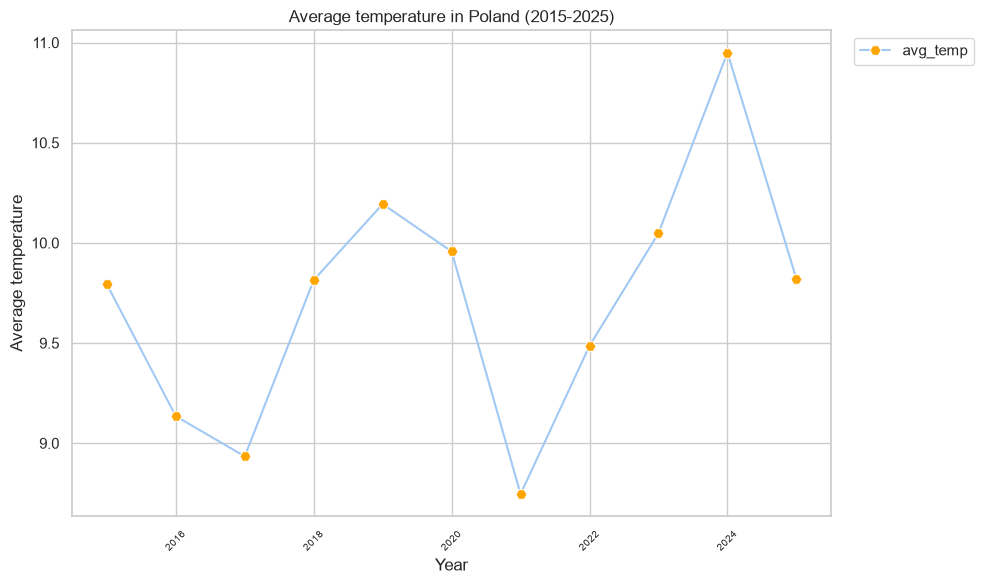

<Figure size 640x480 with 0 Axes>

In [ ]:
# Add a grid in the background
sns.set_theme(
    style="whitegrid", 
    palette="pastel"
)  

# Set figure size
plt.figure(figsize=(10, 6))  

sns.lineplot(
    data=avg_temp_agg,
    marker='H',
    markersize=8,
    markerfacecolor='orange'
    )

plt.title("Average temperature in Poland (2015-2025)") # Title
plt.xlabel("Year") # x-axis name
plt.ylabel("Average temperature") # y-axis name

# Rotate x-axis labels to 45 degrees and reduce labels size
plt.xticks(rotation=45, fontsize=7)

# Position the legend outside the plot:
# X = 1.02 places it slightly to the right of the plot,
# Y = 1.00 aligns it with the top edge.
# The legend's upper-left corner is anchored at this position.
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

# Display the plot
plt.show()

# Save the plot
plt.savefig(
    r"..\02_plots\01_average_temperature.png",
    dpi=300, # Removes unnecessary whitespace around the figure
    bbox_inches="tight" # Setting "tight" automatically crops excess whitespace so labels and titles are not cut off
)

### Annual Average Temperature by Station (2015–2025)

In [94]:
# Group by year and station_name
station_avg_temp = df.groupby(['year', 'station_name']).agg(
    avg_temp=('value', 'mean')).reset_index()

station_avg_temp

,year,station_name,avg_temp
0,2015,Balice,10.015890
1,2015,Bialystok,8.707671
2,2015,Elblag-Milejewo,8.487671
3,2015,Lawica,10.635068
4,2015,Leba,9.150685
...,...,...,...
105,2025,Okecie,11.180085
106,2025,Siedlce,9.345833
107,2025,Strachowice,11.315254
108,2025,Szczecin,10.127500


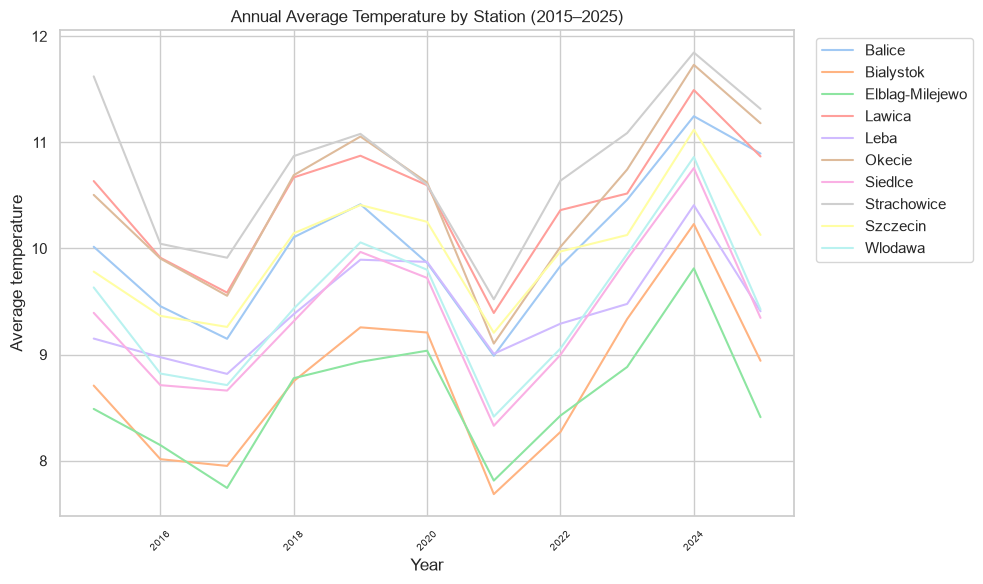

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.set_theme(
    style="whitegrid", 
    palette="pastel"
) 

plt.figure(figsize=(10, 6))  

sns.lineplot(
    data=station_avg_temp, 
    x='year', 
    y='avg_temp', 
    hue='station_name'
)

plt.title("Annual Average Temperature by Station (2015–2025)")
plt.xlabel("Year") 
plt.ylabel("Average temperature") 


plt.xticks(rotation=45, fontsize=7)

plt.legend(
    bbox_to_anchor=(1.02, 1), # 
    loc="upper left"
)
plt.tight_layout()


plt.show()


plt.savefig(
    r"..\02_plots\02_annual_average_temperature_by_station.png",
    dpi=300, 
    bbox_inches="tight" 
)

Annual temperature trends are consistent across all selected weather stations. Although absolute temperatures differ between locations, the year-to-year pattern is similar, with a pronounced decrease in 2021 and a peak in 2024.

### Correlation Between Elevation and Average Temperature

In [82]:
df

,station,station_name,elevation,observation_date,month_year,metric,value,year,min_obs_date,max_obs_date
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0,2015,2015-01-01,2025-12-31
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7,2015,2015-01-01,2025-12-31
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4,2015,2015-01-01,2025-12-31
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0,2015,2015-01-01,2025-12-31
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9,2015,2015-01-01,2025-12-31
...,...,...,...,...,...,...,...,...,...,...
121137,PL000012385,Siedlce,152.0,2025-12-31,12-2025,TAVG,-4.1,2025,2015-01-01,2025-12-31
121141,PLM00012160,Elblag-Milejewo,43.0,2025-12-31,12-2025,TAVG,-4.0,2025,2015-01-01,2025-12-31
121145,PLM00012205,Szczecin,7.0,2025-12-31,12-2025,TAVG,-1.1,2025,2015-01-01,2025-12-31
121149,PLM00012295,Bialystok,151.0,2025-12-31,12-2025,TAVG,-9.2,2025,2015-01-01,2025-12-31


In [92]:
# Group by year and station_name
elev = df.groupby(['year', 'station_name', 'elevation']).agg(
    avg_temp=('value', 'mean')).reset_index()

elev

,year,station_name,elevation,avg_temp
0,2015,Balice,241.1,10.015890
1,2015,Bialystok,151.0,8.707671
2,2015,Elblag-Milejewo,43.0,8.487671
3,2015,Lawica,93.9,10.635068
4,2015,Leba,2.0,9.150685
...,...,...,...,...
105,2025,Okecie,110.3,11.180085
106,2025,Siedlce,152.0,9.345833
107,2025,Strachowice,123.1,11.315254
108,2025,Szczecin,7.0,10.127500


In [ ]:
# Elevation consistency check.
# Verify that each weather station has a consistent elevation value across all 
# observations before analyzing the relationship between elevation and average temperature.
elev_qc = (
    df.groupby(['station_name', 'elevation']).agg(
    observation_count=('elevation', 'count'))
    .sort_values('observation_count', ascending=False)
    .reset_index()
    )

qc = pd.merge(
    elev_qc,
    agg_all,
    on='station_name',
    how='left'
)

# Compare observation counts between both DataFrames.
# .all() returns True only if every station has the same observation count.
if (qc['observation_count_x'] == qc['observation_count_y']).all():
    print("Correct.")
else:
    print("Not correct.")

Correct.


In [ ]:
sns.set_theme(
    style="whitegrid", 
    palette="pastel"
) 

plt.figure(figsize=(10, 6))  

# sns.lineplot(
#     data=, 
#     x='year', 
#     y='avg_temp', 
#     hue='station_name'
# )

plt.title("Correlation Between Elevation and Average Temperature (2015–2025)")
plt.xlabel("Year") 
plt.ylabel("Average temperature") 


plt.xticks(rotation=45, fontsize=7)

plt.legend(
    bbox_to_anchor=(1.02, 1), # 
    loc="upper left"
)
plt.tight_layout()


plt.show()


plt.savefig(
    r"..\02_plots\03_correlation_elevation_avg_temp.png",
    dpi=300, 
    bbox_inches="tight" 
)